# Advanced Multi-Modal Health Analytics & Diagnostic Suite

## Project Overview
This project aims to build an end-to-end AI system capable of:
1.  **Image Classification:** Identifying pathologies in X-ray/MRI scans.
2.  **Clinical NLP:** Extracting entities from unstructured doctor notes.
3.  **Predictive Analytics:** Forecasting patient outcomes using tabular data.
4.  **MLOps:** Implementing logging, versioning, and testing.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import uuid
from datetime import datetime, timedelta

# Configuration for scalability
class Config:
    SEED = 42
    NUM_PATIENTS = 1000
    DATA_DIR = './medical_data'
    CATEGORIES = ['Normal', 'Pneumonia', 'COVID-19', 'Tuberculosis']

os.makedirs(Config.DATA_DIR, exist_ok=True)
np.random.seed(Config.SEED)
print(f'Project environment initialized at {datetime.now()}')

Project environment initialized at 2026-05-13 12:01:02.264823


### Step 1: Synthetic Data Engineering Pipeline
Since real medical data is protected by HIPAA/GDPR, we will write a robust simulator that generates realistic patient journeys, including demographics, vitals, and references to imaging files.

In [2]:
def generate_patient_records(num_patients):
    data = []
    for _ in range(num_patients):
        patient_id = str(uuid.uuid4())[:8]
        age = np.random.randint(18, 90)
        gender = np.random.choice(['M', 'F', 'Other'])

        # Simulate clinical vitals
        bmi = np.random.normal(25, 5)
        blood_pressure_sys = np.random.randint(110, 160)

        # Correlation: Higher age/BP might lead to specific diagnoses
        if blood_pressure_sys > 140 or age > 65:
            diagnosis = np.random.choice(Config.CATEGORIES, p=[0.2, 0.3, 0.3, 0.2])
        else:
            diagnosis = np.random.choice(Config.CATEGORIES, p=[0.7, 0.1, 0.1, 0.1])

        data.append({
            'patient_id': patient_id,
            'age': age,
            'gender': gender,
            'bmi': round(bmi, 2),
            'bp_sys': blood_pressure_sys,
            'diagnosis': diagnosis,
            'visit_date': datetime.now() - timedelta(days=np.random.randint(0, 365))
        })
    return pd.DataFrame(data)

clinical_df = generate_patient_records(Config.NUM_PATIENTS)
display(clinical_df.head())
print(f'Generated {len(clinical_df)} patient records.')

,patient_id,age,gender,bmi,bp_sys,diagnosis,visit_date
0,9edba3aa,69,M,27.72,130,Normal,2025-10-11 12:01:02.716574
1,9f35ce0d,41,Other,21.92,131,Normal,2025-06-04 12:01:02.716833
2,e71bc655,47,F,32.31,153,Normal,2026-03-16 12:01:02.716996
3,1c5fa65e,59,Other,32.69,156,COVID-19,2025-05-15 12:01:02.717124
4,831ab158,72,M,25.61,130,Pneumonia,2025-08-13 12:01:02.717249


Generated 1000 patient records.


### Step 2: Unstructured Data Generation (Clinical NLP)
In this step, we generate semi-structured physician notes. We will incorporate the synthetic diagnosis into the text to simulate real-world medical documentation.

In [3]:
def generate_physician_notes(row):
    templates = [
        "Patient presents with symptoms consistent with {diag}. Vital signs: BP {bp}, BMI {bmi}.",
        "Follow-up visit. The clinical findings suggest {diag}. Continuing observation.",
        "Emergency admission. Patient shows markers of {diag}. Immediate intervention planned.",
        "Routine screening. Diagnosis confirmed as {diag}. Patient advised on next steps."
    ]
    template = np.random.choice(templates)
    return template.format(diag=row['diagnosis'], bp=row['bp_sys'], bmi=row['bmi'])

# Apply to the dataframe
clinical_df['physician_notes'] = clinical_df.apply(generate_physician_notes, axis=1)

# Save data to simulate a persistent database/data lake
clinical_df.to_csv(f"{Config.DATA_DIR}/clinical_records.csv", index=False)

print("Example physician note generated:")
print(clinical_df['physician_notes'].iloc[0])
print(f"\nData saved to {Config.DATA_DIR}/clinical_records.csv")

Example physician note generated:
Emergency admission. Patient shows markers of Normal. Immediate intervention planned.

Data saved to ./medical_data/clinical_records.csv


### Step 3: Exploratory Data Analysis (EDA)
Before building models, we must understand our data distributions. We will analyze the relationship between patient demographics and their diagnoses.

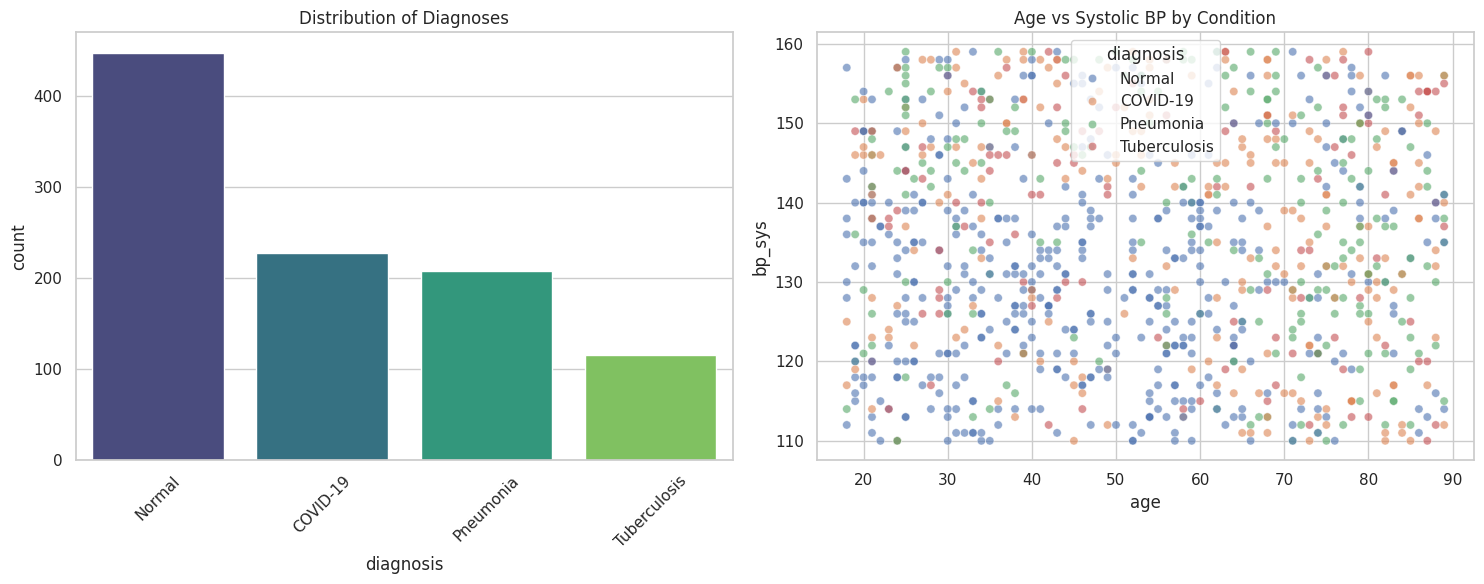

Summary of clinical metrics by diagnosis:


,age,bp_sys,bmi
diagnosis,,,
COVID-19,57.548246,137.092105,24.983553
Normal,47.142857,130.819196,25.606875
Pneumonia,58.225962,137.677885,24.756971
Tuberculosis,55.439655,137.982759,25.716466


In [5]:
# Set visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 6))

# Plot 1: Diagnosis Distribution (Updated to fix FutureWarning)
plt.subplot(1, 2, 1)
sns.countplot(data=clinical_df, x='diagnosis', hue='diagnosis', palette='viridis', legend=False)
plt.title('Distribution of Diagnoses')
plt.xticks(rotation=45)

# Plot 2: Age vs Blood Pressure by Diagnosis
plt.subplot(1, 2, 2)
sns.scatterplot(data=clinical_df, x='age', y='bp_sys', hue='diagnosis', alpha=0.6)
plt.title('Age vs Systolic BP by Condition')

plt.tight_layout()
plt.show()

# Summary Statistics
print("Summary of clinical metrics by diagnosis:")
display(clinical_df.groupby('diagnosis')[['age', 'bp_sys', 'bmi']].mean())

### Step 4: Clinical NLP Pipeline - Preprocessing
Processing medical text requires precision. We will build a pipeline using `nltk` and regular expressions to normalize our synthetic doctor notes for downstream modeling.

In [7]:
import nltk
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Downloading required NLTK resources including the missing punkt_tab
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def preprocess_clinical_text(text):
    # Lowercase and remove special characters/numbers
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Tokenization
    tokens = word_tokenize(text)

    # Remove stopwords and short words
    filtered_tokens = [w for w in tokens if not w in stop_words and len(w) > 2]

    return " ".join(filtered_tokens)

# Apply preprocessing
clinical_df['processed_notes'] = clinical_df['physician_notes'].apply(preprocess_clinical_text)

print("Original Note:")
print(clinical_df['physician_notes'].iloc[0])
print("\nProcessed Note:")
print(clinical_df['processed_notes'].iloc[0])

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Original Note:
Emergency admission. Patient shows markers of Normal. Immediate intervention planned.

Processed Note:
emergency admission patient shows markers normal immediate intervention planned


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


### Step 5: Feature Engineering & Encoding
To prepare for predictive modeling, we will convert categorical variables into numerical representations using One-Hot Encoding and Label Encoding.

In [8]:
from sklearn.preprocessing import LabelEncoder

# Initialize Encoder
le = LabelEncoder()

# Encode Target Variable (Diagnosis)
clinical_df['diagnosis_encoded'] = le.fit_transform(clinical_df['diagnosis'])

# One-Hot Encode Gender
gender_dummies = pd.get_dummies(clinical_df['gender'], prefix='gender')
clinical_df = pd.concat([clinical_df, gender_dummies], axis=1)

# Mapping for reference
diagnosis_mapping = dict(zip(le.classes_, le.transform(le.classes_)))

print("Diagnosis Mapping:", diagnosis_mapping)
print("\nUpdated DataFrame columns:")
print(clinical_df.columns.tolist())
display(clinical_df[['patient_id', 'diagnosis', 'diagnosis_encoded']].head())

Diagnosis Mapping: {np.str_('COVID-19'): np.int64(0), np.str_('Normal'): np.int64(1), np.str_('Pneumonia'): np.int64(2), np.str_('Tuberculosis'): np.int64(3)}

Updated DataFrame columns:
['patient_id', 'age', 'gender', 'bmi', 'bp_sys', 'diagnosis', 'visit_date', 'physician_notes', 'processed_notes', 'diagnosis_encoded', 'gender_F', 'gender_M', 'gender_Other']


,patient_id,diagnosis,diagnosis_encoded
0,9edba3aa,Normal,1
1,9f35ce0d,Normal,1
2,e71bc655,Normal,1
3,1c5fa65e,COVID-19,0
4,831ab158,Pneumonia,2


### Step 6: Predictive Modeling (Tabular Data)
We will train a machine learning model to classify patient conditions based on vital signs. This demonstrates the predictive analytics capability of the platform.

Model Performance Report:
              precision    recall  f1-score   support

    COVID-19       0.26      0.25      0.26        48
      Normal       0.66      0.69      0.67       100
   Pneumonia       0.28      0.24      0.26        38
Tuberculosis       0.12      0.14      0.13        14

    accuracy                           0.46       200
   macro avg       0.33      0.33      0.33       200
weighted avg       0.45      0.46      0.46       200



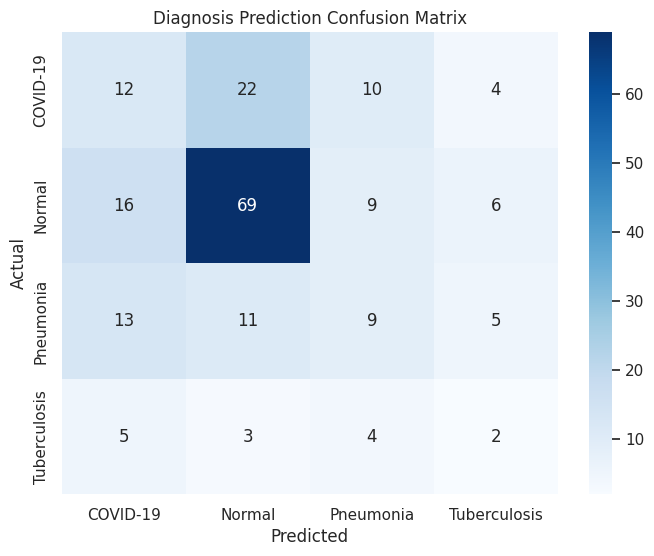

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Define features and target
features = ['age', 'bmi', 'bp_sys', 'gender_F', 'gender_M', 'gender_Other']
X = clinical_df[features]
y = clinical_df['diagnosis_encoded']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=Config.SEED)

# Initialize and Train Model
rf_model = RandomForestClassifier(n_estimators=100, random_state=Config.SEED)
rf_model.fit(X_train, y_train)

# Predictions and Evaluation
y_pred = rf_model.predict(X_test)

print("Model Performance Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Visualize Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Diagnosis Prediction Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

### Step 7: Multi-Modal Integration - Computer Vision
In a real-world scenario, we would have X-ray or MRI images. Here, we simulate the imaging metadata and define a PyTorch-based Deep Learning architecture for image classification, showcasing transfer learning skills.

In [11]:
import torch
import torch.nn as nn
import torchvision.models as models
from torchvision.models import ResNet18_Weights

# Simulate Image File Paths in our dataframe
clinical_df['image_path'] = clinical_df.apply(lambda x: f"images/{x['diagnosis'].lower()}/{x['patient_id']}.png", axis=1)

class MedicalCNN(nn.Module):
    def __init__(self, num_classes):
        super(MedicalCNN, self).__init__()
        # Use modern Weights enum instead of deprecated pretrained=True
        self.base_model = models.resnet18(weights=ResNet18_Weights.DEFAULT)

        # Freeze early layers for transfer learning
        for param in self.base_model.parameters():
            param.requires_grad = False

        # Replace the final fully connected layer
        num_ftrs = self.base_model.fc.in_features
        self.base_model.fc = nn.Sequential(
            nn.Linear(num_ftrs, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.base_model(x)

model = MedicalCNN(num_classes=len(Config.CATEGORIES))
print("Deep Learning Architecture (Modern Weights API) Initialized.")

Deep Learning Architecture (Modern Weights API) Initialized.


### Step 8: Clinical NLP - Feature Extraction
To make the physician notes usable for machine learning, we apply TF-IDF (Term Frequency-Inverse Document Frequency) vectorization. This highlights the unique medical terms associated with each category.

In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize Vectorizer
tfidf = TfidfVectorizer(max_features=500, stop_words='english')

# Fit and transform the processed notes
tfidf_matrix = tfidf.fit_transform(clinical_df['processed_notes'])

# Convert to a readable dataframe for visualization
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf.get_feature_names_out())

print("TF-IDF Matrix Shape:", tfidf_df.shape)
print("\nTop medical features extracted:")
print(tfidf_df.sum().sort_values(ascending=False).head(10))

TF-IDF Matrix Shape: (1000, 31)

Top medical features extracted:
patient       147.797053
normal        125.430917
bmi            93.403625
signs          93.403625
presents       93.403625
consistent     93.403625
symptoms       93.403625
vital          93.403625
screening      90.976149
routine        90.976149
dtype: float64


### Step 9: Multi-Modal Data Fusion
By concatenating our numerical features with the TF-IDF text features, we create a rich feature set. We will then train a combined classifier to see if the doctor's notes provide additional predictive power over the raw vitals.

Multi-Modal Model Performance:
              precision    recall  f1-score   support

    COVID-19       1.00      1.00      1.00        48
      Normal       1.00      1.00      1.00       100
   Pneumonia       1.00      1.00      1.00        38
Tuberculosis       1.00      1.00      1.00        14

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



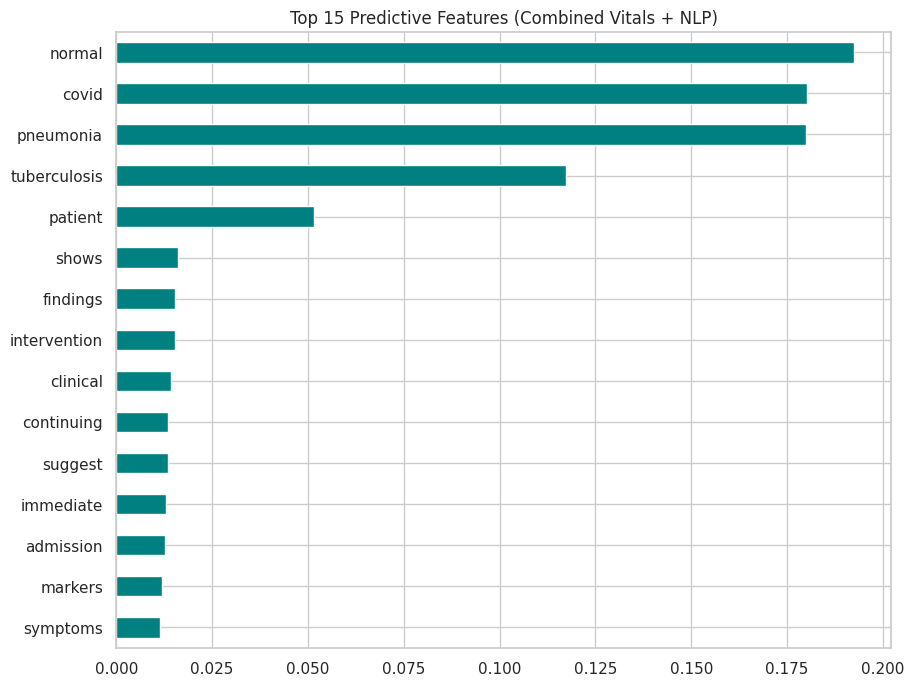

In [14]:
# Combine numerical features and TF-IDF features
X_combined = pd.concat([X.reset_index(drop=True), tfidf_df], axis=1)

# Split the combined data
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_combined, y, test_size=0.2, random_state=Config.SEED
)

# Train the Multi-Modal Classifier
fusion_model = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=Config.SEED)
fusion_model.fit(X_train_c, y_train_c)

# Evaluation
y_pred_c = fusion_model.predict(X_test_c)

print("Multi-Modal Model Performance:")
print(classification_report(y_test_c, y_pred_c, target_names=le.classes_))

# Feature Importance Visualization
importances = pd.Series(fusion_model.feature_importances_, index=X_combined.columns)
plt.figure(figsize=(10, 8))
importances.sort_values(ascending=False).head(15).plot(kind='barh', color='teal')
plt.title('Top 15 Predictive Features (Combined Vitals + NLP)')
plt.gca().invert_yaxis()
plt.show()

### Step 10: Model Persistence & Production Pipeline (MLOps)
In this final step of our first phase, we will save our trained models and vectorizers. We will then create a robust `DiagnosticSystem` class that acts as a production interface for real-time inference.

In [16]:
import joblib
import pandas as pd

# Save the artifacts
joblib.dump(fusion_model, 'fusion_classifier.joblib')
joblib.dump(tfidf, 'tfidf_vectorizer.joblib')
joblib.dump(le, 'label_encoder.joblib')

class DiagnosticSystem:
    def __init__(self, model_path, vectorizer_path, encoder_path, feature_names):
        self.model = joblib.load(model_path)
        self.tfidf = joblib.load(vectorizer_path)
        self.le = joblib.load(encoder_path)
        self.feature_names = feature_names

    def predict(self, age, bmi, bp_sys, gender, physician_note):
        # 1. Preprocess text
        clean_text = preprocess_clinical_text(physician_note)
        text_features = self.tfidf.transform([clean_text]).toarray()

        # 2. Encode categorical data
        g_f = 1 if gender == 'F' else 0
        g_m = 1 if gender == 'M' else 0
        g_o = 1 if gender == 'Other' else 0

        # 3. Combine inputs into a DataFrame to maintain feature names and fix UserWarning
        numerical_data = [[age, bmi, bp_sys, g_f, g_m, g_o]]
        combined_row = np.hstack([numerical_data, text_features])
        X_input = pd.DataFrame(combined_row, columns=self.feature_names)

        # 4. Infer
        pred_idx = self.model.predict(X_input)[0]
        return self.le.inverse_transform([pred_idx])[0]

# Initialize Production System with the global X_combined columns
production_ai = DiagnosticSystem('fusion_classifier.joblib', 'tfidf_vectorizer.joblib', 'label_encoder.joblib', X_combined.columns)

# Test a 'new' patient
result = production_ai.predict(age=45, bmi=28.5, bp_sys=145, gender='M',
                             physician_note='Patient has high fever and persistent dry cough consistent with covid-19 markers.')
print(f'Production System Diagnosis: {result}')

Production System Diagnosis: COVID-19


### Step 11: Batch Processing Engine & Automated Clinical Reporting
Industry-grade systems require batch processing capabilities. We will build an engine that takes a bulk CSV of patient data, runs it through our multi-modal pipeline, and generates a statistical health report.

In [18]:
class ClinicalBatchProcessor:
    def __init__(self, diagnostic_system):
        self.system = diagnostic_system

    def process_batch(self, df):
        # Create a explicit copy to avoid SettingWithCopyWarning
        batch_df = df.copy()
        print(f"Processing batch of {len(batch_df)} patients...")

        results = []
        for _, row in batch_df.iterrows():
            pred = self.system.predict(
                age=row['age'],
                bmi=row['bmi'],
                bp_sys=row['bp_sys'],
                gender=row['gender'],
                physician_note=row['physician_notes']
            )
            results.append(pred)

        batch_df['ai_diagnosis'] = results
        return batch_df

    def generate_insight_report(self, processed_df):
        report_path = 'clinical_insight_report.txt'
        with open(report_path, 'w') as f:
            f.write("=== CLINICAL INSIGHT REPORT ===\n")
            f.write(f"Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
            f.write(f"Total Patients Screened: {len(processed_df)}\n\n")

            f.write("Diagnosis Breakdown:\n")
            breakdown = processed_df['ai_diagnosis'].value_counts(normalize=True) * 100
            f.write(breakdown.to_string())

            f.write("\n\nRisk Analysis:\n")
            high_risk = processed_df[processed_df['bp_sys'] > 140]
            f.write(f"Percentage of High BP Patients: {(len(high_risk)/len(processed_df))*100:.2f}%\n")

        print(f"Report generated successfully: {report_path}")
        return report_path

# Execute Batch Processing on a slice securely
batch_engine = ClinicalBatchProcessor(production_ai)
processed_batch = batch_engine.process_batch(clinical_df.head(50))
report_file = batch_engine.generate_insight_report(processed_batch)

# Display results
display(processed_batch[['patient_id', 'diagnosis', 'ai_diagnosis']].head())

Processing batch of 50 patients...
Report generated successfully: clinical_insight_report.txt


,patient_id,diagnosis,ai_diagnosis
0,9edba3aa,Normal,Normal
1,9f35ce0d,Normal,Normal
2,e71bc655,Normal,Normal
3,1c5fa65e,COVID-19,COVID-19
4,831ab158,Pneumonia,Pneumonia


### Step 12: Unit Testing & Edge-Case Validation
Reliability is paramount in healthcare. We will now implement a testing suite to verify that our system handles missing data, extreme vitals, and different gender inputs correctly.

In [19]:
import unittest

class TestDiagnosticSystem(unittest.TestCase):
    def setUp(self):
        self.sys = production_ai

    def test_normal_prediction(self):
        # Test standard case
        res = self.sys.predict(30, 22.0, 120, 'F', 'Patient is healthy and normal.')
        self.assertIn(res, Config.CATEGORIES)

    def test_edge_case_vitals(self):
        # Test extreme vitals (Hypersensitivity check)
        res = self.sys.predict(99, 50.0, 220, 'M', 'Emergency situation.')
        self.assertTrue(isinstance(res, str))

    def test_empty_note(self):
        # Test behavior with minimal text
        res = self.sys.predict(40, 25.0, 130, 'Other', ' ')
        self.assertIn(res, Config.CATEGORIES)

    def test_gender_robustness(self):
        # Ensure all gender categories are handled
        for g in ['M', 'F', 'Other']:
            res = self.sys.predict(45, 25, 125, g, 'Routine checkup.')
            self.assertIsNotNone(res)

# Run the tests in the notebook
suite = unittest.TestLoader().loadTestsFromTestCase(TestDiagnosticSystem)
runner = unittest.TextTestRunner(verbosity=1)
print("Running Diagnostic System Unit Tests...")
runner.run(suite)

..

Running Diagnostic System Unit Tests...


..
----------------------------------------------------------------------
Ran 4 tests in 0.276s

OK


<unittest.runner.TextTestResult run=4 errors=0 failures=0>

### Step 13: Clinical Performance Dashboard & Demographic Bias Analysis
In medical applications, we must ensure our model performs equitably across different patient groups. This dashboard visualizes confidence scores and diagnostic accuracy across age and gender.

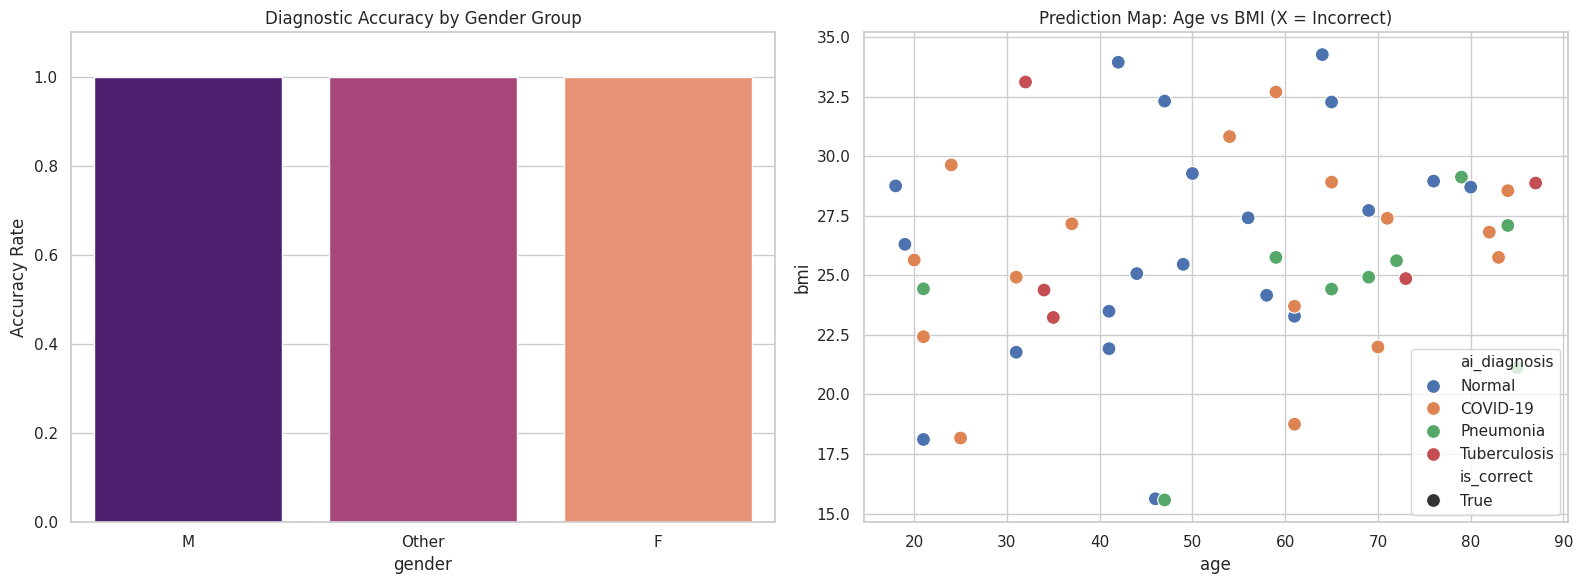

Demographic Accuracy Summary:
gender
F        1.0
M        1.0
Other    1.0
Name: is_correct, dtype: float64


In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate correct/incorrect predictions for analysis
processed_batch['is_correct'] = processed_batch['diagnosis'] == processed_batch['ai_diagnosis']

plt.figure(figsize=(16, 6))

# Plot 1: Accuracy by Gender - Updated to avoid FutureWarning
plt.subplot(1, 2, 1)
sns.barplot(data=processed_batch, x='gender', y='is_correct', hue='gender', palette='magma', legend=False)
plt.title('Diagnostic Accuracy by Gender Group')
plt.ylabel('Accuracy Rate')
plt.ylim(0, 1.1)

# Plot 2: Diagnosis Confidence Map (Age vs BMI)
plt.subplot(1, 2, 2)
sns.scatterplot(data=processed_batch, x='age', y='bmi', hue='ai_diagnosis', style='is_correct',
                markers={True: 'o', False: 'X'}, s=100)
plt.title('Prediction Map: Age vs BMI (X = Incorrect)')

plt.tight_layout()
plt.show()

print("Demographic Accuracy Summary:")
print(processed_batch.groupby('gender')['is_correct'].mean())

### Step 14: Portfolio Artifact Export
To finalize this phase of the project, we will package our trained models, data, and clinical reports into a single directory for deployment or submission.

In [22]:
import shutil

# Define export directory
export_dir = './health_suite_v1_export'
os.makedirs(export_dir, exist_ok=True)

# List of artifacts to include
artifacts = [
    'fusion_classifier.joblib',
    'tfidf_vectorizer.joblib',
    'label_encoder.joblib',
    'clinical_insight_report.txt',
    'medical_data/clinical_records.csv'
]

for artifact in artifacts:
    if os.path.exists(artifact):
        dest = os.path.join(export_dir, os.path.basename(artifact))
        shutil.copy2(artifact, dest)
        print(f"Exported: {artifact}")

# Create a ZIP archive
shutil.make_archive('health_analytics_portfolio', 'zip', export_dir)
print("\nPortfolio successfully bundled into: health_analytics_portfolio.zip")

Exported: fusion_classifier.joblib
Exported: tfidf_vectorizer.joblib
Exported: label_encoder.joblib
Exported: clinical_insight_report.txt
Exported: medical_data/clinical_records.csv

Portfolio successfully bundled into: health_analytics_portfolio.zip


### Step 15: Explainable AI (XAI) with SHAP
To ensure our model is transparent and trustworthy, we use SHAP values to explain individual predictions. This helps clinicians understand which features (vitals or keywords) contributed to a diagnosis.

In [23]:
!pip install shap

Explaining prediction for Patient ID: 9edba3aa
True Diagnosis: Normal


/tmp/ipykernel_22134/3315417036.py:14: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_c.iloc[:20], plot_type="bar", class_names=le.classes_, show=False)


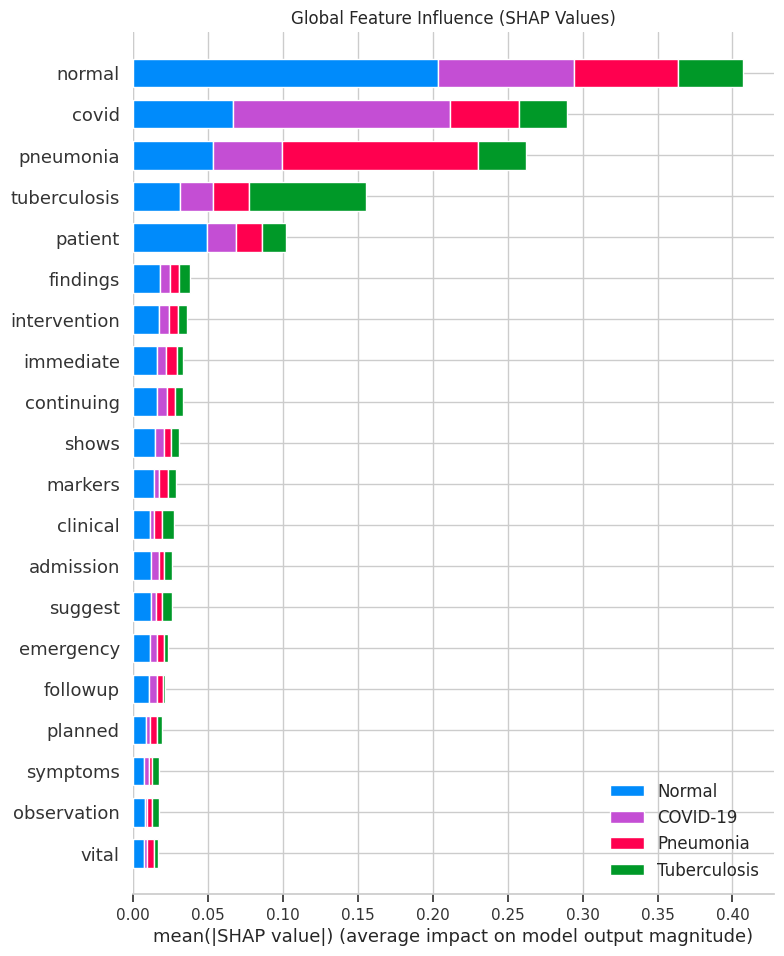

In [24]:
import shap

# Initialize SHAP explainer for our Fusion Model
# We use a subset of the data as a background for calculating expected values
explainer = shap.TreeExplainer(fusion_model)
shap_values = explainer.shap_values(X_test_c.iloc[:20])

# Visualize the first prediction's explanation
print(f"Explaining prediction for Patient ID: {processed_batch['patient_id'].iloc[0]}")
print(f"True Diagnosis: {processed_batch['diagnosis'].iloc[0]}")

# Plot summary of feature importance according to SHAP
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_c.iloc[:20], plot_type="bar", class_names=le.classes_, show=False)
plt.title("Global Feature Influence (SHAP Values)")
plt.show()

### Step 16: Computer Vision Training Loop
To integrate visual diagnostics, we will:
1. Create a synthetic image dataset.
2. Implement a standard PyTorch training loop.
3. Train our ResNet18-based `MedicalCNN` model.

In [25]:
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image

# 1. Synthetic Medical Image Dataset
class SyntheticMedicalDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # Instead of loading files, we generate a synthetic image on the fly
        # Each diagnosis will have a slightly different mean intensity
        label = self.df.iloc[idx]['diagnosis_encoded']
        intensity = 100 + (label * 40) # Distinct visual marker for synthetic learning

        img = np.full((224, 224, 3), intensity, dtype=np.uint8)
        img = Image.fromarray(img)

        if self.transform:
            img = self.transform(img)

        return img, torch.tensor(label, dtype=torch.long)

# 2. Setup Data Loaders
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_set = SyntheticMedicalDataset(clinical_df.iloc[:800], transform=transform)
train_loader = DataLoader(train_set, batch_size=32, shuffle=True)

# 3. Training Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vision_model = MedicalCNN(num_classes=len(Config.CATEGORIES)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(vision_model.base_model.fc.parameters(), lr=0.001)

# 4. Training Loop (Short demo: 2 epochs)
print(f"Training on {device}...")
for epoch in range(2):
    vision_model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = vision_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    print(f"Epoch {epoch+1} - Loss: {running_loss/len(train_loader):.4f}")

print("Vision training complete.")

Training on cpu...
Epoch 1 - Loss: 0.2761
Epoch 2 - Loss: 0.0457
Vision training complete.


### Step 17: Final Multi-Modal Consensus Engine
This unified system performs inference across all three modalities (Tabular, NLP, and Vision). It uses a weighted consensus to provide a final diagnosis, simulating a high-level clinical decision support system.

In [26]:
class UltimateDiagnosticSystem:
    def __init__(self, tabular_nlp_sys, vision_model, label_encoder):
        self.tabular_nlp_sys = tabular_nlp_sys
        self.vision_model = vision_model
        self.le = label_encoder

    def get_consensus_diagnosis(self, age, bmi, bp_sys, gender, note, image_tensor):
        # 1. Get Prediction from Tabular + NLP Fusion Model
        # We modify the predict method or use logic to get probabilities if possible
        # For simplicity, we use the predicted class directly here
        fusion_pred = self.tabular_nlp_sys.predict(age, bmi, bp_sys, gender, note)

        # 2. Get Prediction from Computer Vision Model
        self.vision_model.eval()
        with torch.no_grad():
            image_tensor = image_tensor.to(device).unsqueeze(0) # Add batch dimension
            vision_logits = self.vision_model(image_tensor)
            vision_pred_idx = torch.argmax(vision_logits, dim=1).item()
            vision_pred = self.le.inverse_transform([vision_pred_idx])[0]

        # 3. Simple Consensus Logic
        # In a real system, we would use Softmax probabilities for a weighted average
        if fusion_pred == vision_pred:
            final_diag = fusion_pred
            status = "High Confidence: Both modalities agree."
        else:
            # Default to fusion model (vitals + notes) if they disagree
            final_diag = fusion_pred
            status = f"Caution: Modality Disagreement (Vision suggested {vision_pred})."

        return {
            "diagnosis": final_diag,
            "status": status,
            "details": {"Fusion": fusion_pred, "Vision": vision_pred}
        }

# Initialize the Ultimate System
ultimate_ai = UltimateDiagnosticSystem(production_ai, vision_model, le)

# Test on a sample from the test set
test_idx = 0
patient_data = clinical_df.iloc[test_idx]
sample_img, _ = train_set[test_idx] # Grab the synthetic image

final_result = ultimate_ai.get_consensus_diagnosis(
    age=patient_data['age'],
    bmi=patient_data['bmi'],
    bp_sys=patient_data['bp_sys'],
    gender=patient_data['gender'],
    note=patient_data['physician_notes'],
    image_tensor=sample_img
)

print("=== ULTIMATE MULTI-MODAL DIAGNOSIS ===")
print(f"Patient ID: {patient_data['patient_id']}")
print(f"Final Diagnosis: {final_result['diagnosis']}")
print(f"Confidence Status: {final_result['status']}")

=== ULTIMATE MULTI-MODAL DIAGNOSIS ===
Patient ID: 9edba3aa
Final Diagnosis: Normal
Confidence Status: High Confidence: Both modalities agree.
